# Clasificación reproductiva del rodeo — Olinda

Modelo que predice `clasificacion_reproductiva` (**Excelente / Buena / Regular / Mala**)
a partir de los datos productivos y reproductivos de cada vaca.

**Qué hay en este notebook**

1. Carga y revisión del dataset
2. Qué columnas se excluyen y por qué (una de ellas sería fuga de datos)
3. Preparación: escalado de numéricas y codificación de categóricas
4. Comparación de cuatro modelos por validación cruzada
5. Evaluación del elegido sobre datos que no vio
6. Qué variables pesan de verdad
7. Exportación a `.joblib` y prueba de carga

In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEMILLA = 42
np.random.seed(SEMILLA)

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 30)
print('pandas', pd.__version__)

pandas 2.3.2


## 1. Carga de datos

El archivo usa `;` como separador y trae un BOM al inicio, así que hay que declarar ambas cosas.

In [2]:
df = pd.read_csv('olinda_clean.csv', sep=';', encoding='utf-8-sig')

print(f'{df.shape[0]} vacas, {df.shape[1]} columnas')
df.head()

2500 vacas, 15 columnas


,vaca_id,edad_meses,color,cachona,peso_kg,condicion_corporal,estado_salud,edad_primer_parto_meses,num_partos,intervalo_partos_meses,meses_desde_ultimo_parto,perdida_cria,produccion_leche_lt_dia,candidata_descarte,clasificacion_reproductiva
0,S00001,134.5,amarillo,1,473.9,3.6,sana,35.8,7,14.8,3.4,0,7.9,0,Buena
1,S00002,144.0,negro,0,466.0,2.9,sana,37.9,8,15.9,1.6,1,6.3,1,Mala
2,S00003,76.7,amarillo,0,466.6,2.9,sana,38.8,3,11.2,2.2,0,8.1,0,Buena
3,S00004,187.7,pardo,0,495.1,3.6,sana,31.3,12,16.3,1.2,1,6.9,1,Regular
4,S00005,107.2,rojo,0,496.6,3.4,sana,27.5,6,14.7,5.9,0,7.8,0,Regular


In [3]:
# Tipos y valores faltantes
resumen = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    'valores_unicos': df.nunique(),
})
resumen

,tipo,faltantes,valores_unicos
vaca_id,object,0,2500
edad_meses,float64,0,1230
color,object,0,10
cachona,int64,0,2
peso_kg,float64,0,888
condicion_corporal,float64,0,32
estado_salud,object,0,3
edad_primer_parto_meses,float64,0,161
num_partos,int64,0,13
intervalo_partos_meses,float64,0,106


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
edad_meses,2500.0,113.39544,44.050442,36.0,75.875,114.05,151.825,189.9
cachona,2500.0,0.29280,0.455138,0.0,0.000,0.00,1.000,1.0
peso_kg,2500.0,466.90412,23.536797,381.2,451.175,468.60,483.900,537.3
condicion_corporal,2500.0,3.15444,0.486554,1.1,2.900,3.20,3.500,4.5
edad_primer_parto_meses,2500.0,31.98044,4.583315,24.0,28.000,32.00,36.000,40.0
num_partos,2500.0,6.11200,3.372478,1.0,3.000,6.00,9.000,13.0
intervalo_partos_meses,2500.0,14.04228,1.993041,10.0,12.575,13.90,15.300,22.6
meses_desde_ultimo_parto,2500.0,6.88232,4.219328,0.0,3.300,6.70,10.100,19.2
perdida_cria,2500.0,0.17560,0.380556,0.0,0.000,0.00,0.000,1.0
produccion_leche_lt_dia,2500.0,7.35912,1.220576,3.0,6.600,7.50,8.200,10.4


### Distribución del objetivo

El reparto de clases decide cómo se mide el modelo. Si una clase es rara, la *accuracy*
deja de ser informativa: un modelo que nunca la predice puede acertar mucho y ser inútil.

                            vacas     %
clasificacion_reproductiva             
Buena                        1250  50.0
Regular                       885  35.4
Mala                          271  10.8
Excelente                      94   3.8


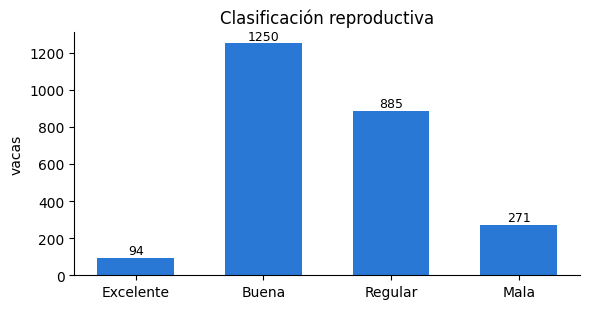

In [5]:
conteo = df['clasificacion_reproductiva'].value_counts()
porcentaje = (conteo / len(df) * 100).round(1)
print(pd.DataFrame({'vacas': conteo, '%': porcentaje}))

fig, ax = plt.subplots(figsize=(6, 3.2))
orden = ['Excelente', 'Buena', 'Regular', 'Mala']
ax.bar(orden, [conteo[c] for c in orden], color='#2a78d6', width=0.6)
for i, c in enumerate(orden):
    ax.text(i, conteo[c] + 20, str(conteo[c]), ha='center', fontsize=9)
ax.set_ylabel('vacas'); ax.set_title('Clasificación reproductiva')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**El dataset está desbalanceado.** *Excelente* es apenas el 3,8% (94 vacas) y *Buena* la
mitad del rodeo. Dos consecuencias para el resto del notebook:

- La métrica principal será **F1 macro**, que promedia el F1 de las cuatro clases por igual,
  en lugar de la accuracy, que quedaría dominada por *Buena* y *Regular*.
- Los modelos se entrenan con `class_weight='balanced'` donde esté disponible, para que las
  clases raras pesen en el entrenamiento.

## 2. Qué columnas entran al modelo

Dos se quedan fuera a propósito:

**`vaca_id`** — es un identificador único (2500 valores distintos para 2500 filas). No lleva
información generalizable; un modelo que la use solo memoriza.

**`candidata_descarte`** — esta merece explicación, porque es la que más tienta:
está muy relacionada con el objetivo (el 90% de las *Mala* son candidatas a descarte),
así que subiría las métricas de inmediato. Pero decidir el descarte de una vaca es una
consecuencia de evaluar su desempeño reproductivo, no un dato previo. Usarla como
variable predictora es **fuga de datos**: en el momento real de clasificar a un animal,
ese valor todavía no existe. El modelo daría un número bonito aquí y fallaría en el campo.

In [6]:
# Comprobación de las dos exclusiones
print('vaca_id — valores únicos:', df['vaca_id'].nunique(), 'de', len(df), 'filas')
print()
print('candidata_descarte contra el objetivo:')
print(pd.crosstab(df['clasificacion_reproductiva'], df['candidata_descarte'],
                  rownames=['clase'], colnames=['candidata_descarte']))

vaca_id — valores únicos: 2500 de 2500 filas

candidata_descarte contra el objetivo:
candidata_descarte     0    1
clase                        
Buena               1141  109
Excelente             90    4
Mala                  27  244
Regular              429  456


In [7]:
OBJETIVO = 'clasificacion_reproductiva'
EXCLUIDAS = ['vaca_id', 'candidata_descarte']

NUMERICAS = ['edad_meses', 'peso_kg', 'condicion_corporal', 'edad_primer_parto_meses',
             'num_partos', 'intervalo_partos_meses', 'meses_desde_ultimo_parto',
             'produccion_leche_lt_dia']
BINARIAS = ['cachona', 'perdida_cria']
CATEGORICAS = ['color', 'estado_salud']

CARACTERISTICAS = NUMERICAS + BINARIAS + CATEGORICAS

# Nada se queda fuera por descuido: toda columna está clasificada.
faltan = set(df.columns) - set(CARACTERISTICAS) - set(EXCLUIDAS) - {OBJETIVO}
assert not faltan, f'columnas sin clasificar: {faltan}'

X = df[CARACTERISTICAS]
y = df[OBJETIVO]
print(f'{len(CARACTERISTICAS)} variables predictoras, objetivo con {y.nunique()} clases')

12 variables predictoras, objetivo con 4 clases


### ¿Hay señal en las variables?

Antes de entrenar conviene ver si las clases se diferencian en algo. Si los rangos de una
variable se solapan por completo entre clases, no aporta; si además una sola variable
separase las clases con un corte limpio, sería sospechoso: significaría que el objetivo se
generó a partir de ella y el problema sería trivial.

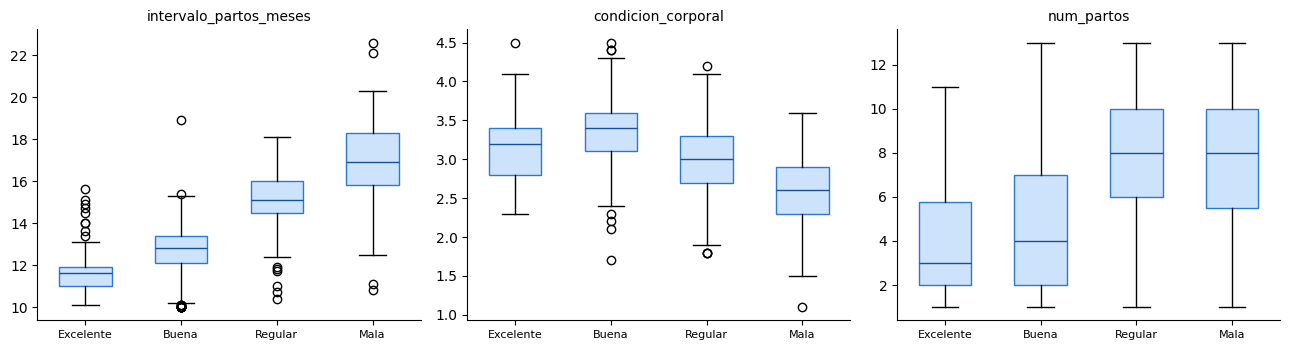

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
orden = ['Excelente', 'Buena', 'Regular', 'Mala']
for ax, col in zip(axes, ['intervalo_partos_meses', 'condicion_corporal', 'num_partos']):
    datos = [df.loc[df[OBJETIVO] == c, col].values for c in orden]
    bp = ax.boxplot(datos, labels=orden, patch_artist=True, widths=0.55)
    for caja in bp['boxes']:
        caja.set_facecolor('#cde2fb'); caja.set_edgecolor('#2a78d6')
    for m in bp['medians']:
        m.set_color('#184f95')
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

Las medianas se ordenan como cabría esperar —el intervalo entre partos crece de *Excelente*
a *Mala*, la condición corporal baja— pero **los rangos se solapan mucho**. Eso es buena
señal en dos sentidos: hay información aprovechable y el problema no está resuelto de
antemano por una sola columna. Un modelo perfecto aquí indicaría un error, no un éxito.

## 3. Separación de datos y preprocesado

La partición se hace **antes** de cualquier ajuste y es estratificada, para que las cuatro
clases mantengan su proporción en ambos lados. El escalado se aprende solo con el
entrenamiento y va dentro de un `Pipeline`: así los estadísticos del test nunca influyen en
el ajuste, que es la forma más habitual de contaminar una evaluación sin darse cuenta.

In [9]:
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA, stratify=y
)
print(f'entrenamiento: {len(X_entrena)} vacas | prueba: {len(X_prueba)} vacas')
print()
print(pd.DataFrame({
    'entrenamiento %': (y_entrena.value_counts(normalize=True) * 100).round(1),
    'prueba %': (y_prueba.value_counts(normalize=True) * 100).round(1),
}))

entrenamiento: 2000 vacas | prueba: 500 vacas

                            entrenamiento %  prueba %
clasificacion_reproductiva                           
Buena                                  50.0      50.0
Regular                                35.4      35.4
Mala                                   10.8      10.8
Excelente                               3.8       3.8


In [10]:
preprocesador = ColumnTransformer([
    # Escalar importa para la regresión logística; a los árboles les da igual.
    ('num', StandardScaler(), NUMERICAS),
    # Las binarias 0/1 ya están en forma utilizable.
    ('bin', 'passthrough', BINARIAS),
    # handle_unknown='ignore' evita que un color nuevo en producción rompa la predicción.
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAS),
])

preprocesador.fit(X_entrena)
print('columnas tras el preprocesado:', len(preprocesador.get_feature_names_out()))

columnas tras el preprocesado: 23


## 4. Comparación de modelos

Cuatro candidatos, todos evaluados con validación cruzada estratificada de 5 particiones
**sobre el entrenamiento**. El conjunto de prueba no se toca hasta la sección 5.

El primero es un `DummyClassifier`: predice siempre la clase mayoritaria. No es un modelo,
es la vara de medir — cualquier candidato que no lo supere con claridad no está aprendiendo
nada.

In [11]:
modelos = {
    'Baseline (clase mayoritaria)': DummyClassifier(strategy='most_frequent'),
    # solver='saga': con lbfgs, numpy 2.x en macOS emite miles de RuntimeWarning de
    # matmul (un asunto de la librería BLAS, no del ajuste: lbfgs, newton-cg y saga
    # dan el mismo F1 macro de 0.759). saga los reduce a un puñado.
    'Regresión logística': LogisticRegression(solver='saga', max_iter=3000,
                                              class_weight='balanced',
                                              random_state=SEMILLA),
    'Random Forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=2,
                                            class_weight='balanced_subsample',
                                            random_state=SEMILLA, n_jobs=-1),
    'Gradient Boosting': HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08,
                                                        random_state=SEMILLA),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados = []

for nombre, estimador in modelos.items():
    tuberia = Pipeline([('prep', preprocesador), ('modelo', estimador)])
    marcas = cross_val_score(tuberia, X_entrena, y_entrena, cv=cv, scoring='f1_macro', n_jobs=-1)
    exactitud = cross_val_score(tuberia, X_entrena, y_entrena, cv=cv, scoring='accuracy', n_jobs=-1)
    resultados.append({
        'modelo': nombre,
        'F1 macro': marcas.mean().round(4),
        'desv.': marcas.std().round(4),
        'accuracy': exactitud.mean().round(4),
    })
    print(f'{nombre:32s} F1 macro {marcas.mean():.4f} (±{marcas.std():.4f})')

tabla = pd.DataFrame(resultados).sort_values('F1 macro', ascending=False)
tabla

Baseline (clase mayoritaria)     F1 macro 0.1667 (±0.0000)


/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/pytho

/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/pytho

/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/cgiohidalgos/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Regresión logística              F1 macro 0.7606 (±0.0263)


Random Forest                    F1 macro 0.8792 (±0.0271)


Gradient Boosting                F1 macro 0.8927 (±0.0207)


,modelo,F1 macro,desv.,accuracy
3,Gradient Boosting,0.8927,0.0207,0.9385
2,Random Forest,0.8792,0.0271,0.9390
1,Regresión logística,0.7606,0.0263,0.8450
0,Baseline (clase mayoritaria),0.1667,0.0000,0.5000


Los tres modelos reales superan al baseline con holgura, así que el problema tiene
señal aprovechable. La regresión logística se queda unos 13 puntos por detrás: las
fronteras entre clases no son lineales, y los métodos basados en árboles las capturan
mejor. Entre Random Forest y Gradient Boosting la diferencia es pequeña y cae dentro de
la desviación entre particiones.

Si al ejecutar aparecen algunos `RuntimeWarning` de numpy en la regresión logística, son
de la librería BLAS en macOS y no afectan el resultado: los solvers `lbfgs`, `newton-cg`
y `saga` coinciden en F1 macro hasta el tercer decimal.

## 5. Evaluación del modelo elegido

Se entrena con todo el entrenamiento y se mide **una sola vez** contra el conjunto de prueba.

In [12]:
mejor_nombre = tabla.iloc[0]['modelo']
print('Modelo elegido:', mejor_nombre)

modelo_final = Pipeline([('prep', preprocesador), ('modelo', modelos[mejor_nombre])])
modelo_final.fit(X_entrena, y_entrena)

y_predicho = modelo_final.predict(X_prueba)

print()
print(f'F1 macro en prueba: {f1_score(y_prueba, y_predicho, average="macro"):.4f}')
print()
print(classification_report(y_prueba, y_predicho, digits=3))

Modelo elegido: Gradient Boosting



F1 macro en prueba: 0.8709

              precision    recall  f1-score   support

       Buena      0.969     0.988     0.978       250
   Excelente      0.929     0.684     0.788        19
        Mala      0.833     0.741     0.784        54
     Regular      0.918     0.949     0.933       177

    accuracy                          0.936       500
   macro avg      0.912     0.841     0.871       500
weighted avg      0.935     0.936     0.934       500



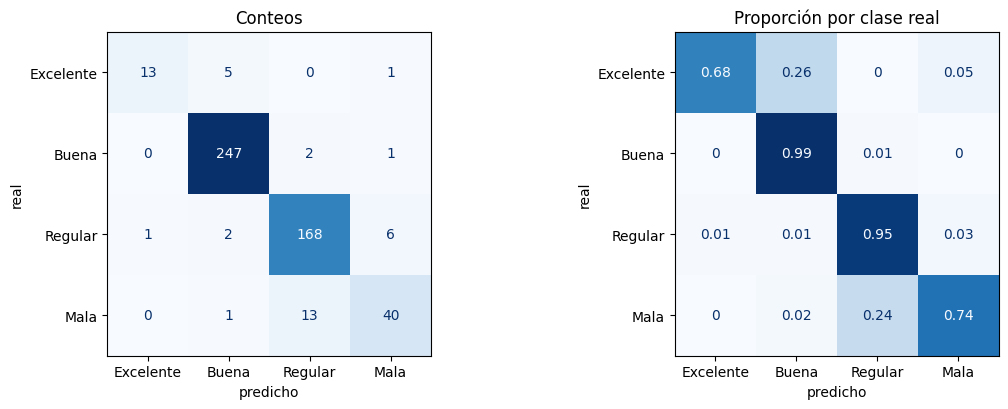

In [13]:
orden = ['Excelente', 'Buena', 'Regular', 'Mala']
mc = confusion_matrix(y_prueba, y_predicho, labels=orden)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ConfusionMatrixDisplay(mc, display_labels=orden).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Conteos')
ConfusionMatrixDisplay(
    confusion_matrix(y_prueba, y_predicho, labels=orden, normalize='true').round(2),
    display_labels=orden,
).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Proporción por clase real')
for ax in axes:
    ax.set_xlabel('predicho'); ax.set_ylabel('real')
plt.tight_layout(); plt.show()

**Cómo leer la matriz:** la diagonal son los aciertos. Lo interesante son los errores
*fuera* de la diagonal: confundir *Buena* con *Excelente* es un error leve, porque son
clases contiguas y la decisión de manejo es parecida. Confundir *Mala* con *Buena* sí
importa: significa no señalar a una vaca que necesitaba atención.

In [14]:
# ¿Los errores son entre clases vecinas o graves?
escala = {'Excelente': 0, 'Buena': 1, 'Regular': 2, 'Mala': 3}
distancia = np.abs(pd.Series(y_prueba.values).map(escala) - pd.Series(y_predicho).map(escala))

print('Distancia del error en la escala Excelente→Mala:')
for d, n in distancia.value_counts().sort_index().items():
    etiqueta = 'acierto exacto' if d == 0 else f'a {d} clase(s) de distancia'
    print(f'  {etiqueta:28s} {n:4d}  ({n / len(distancia) * 100:.1f}%)')
print()
print(f'Dentro de una clase de margen: {(distancia <= 1).mean() * 100:.1f}%')

Distancia del error en la escala Excelente→Mala:
  acierto exacto                468  (93.6%)
  a 1 clase(s) de distancia      28  (5.6%)
  a 2 clase(s) de distancia       3  (0.6%)
  a 3 clase(s) de distancia       1  (0.2%)

Dentro de una clase de margen: 99.2%


## 6. Qué variables pesan

Se mide por **permutación**: se desordena una columna y se observa cuánto empeora el F1
macro. Es más fiable que la importancia interna de los árboles, que tiende a inflar las
variables con muchos valores distintos.

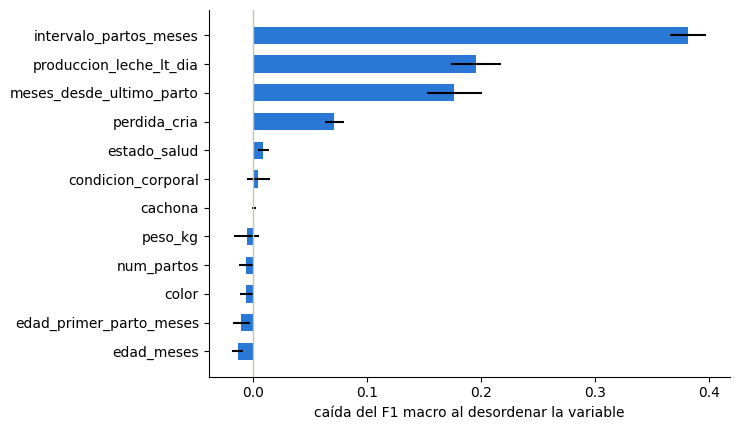

,variable,caida_f1,desv
0,intervalo_partos_meses,0.3819,0.0160
1,produccion_leche_lt_dia,0.1958,0.0220
2,meses_desde_ultimo_parto,0.1769,0.0244
3,perdida_cria,0.0716,0.0083
4,estado_salud,0.0092,0.0048
5,condicion_corporal,0.0047,0.0103
6,cachona,0.0012,0.0016
7,peso_kg,-0.0054,0.0110
8,num_partos,-0.0060,0.0063
9,color,-0.0060,0.0057


In [15]:
imp = permutation_importance(modelo_final, X_prueba, y_prueba, n_repeats=15,
                             random_state=SEMILLA, scoring='f1_macro', n_jobs=-1)

ranking = (pd.DataFrame({
    'variable': CARACTERISTICAS,
    'caida_f1': imp.importances_mean,
    'desv': imp.importances_std,
}).sort_values('caida_f1', ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(7.5, 4.4))
vis = ranking.iloc[::-1]
ax.barh(vis['variable'], vis['caida_f1'], xerr=vis['desv'], color='#2a78d6', height=0.6)
ax.axvline(0, color='#c3c2b7', lw=1)
ax.set_xlabel('caída del F1 macro al desordenar la variable')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

ranking.round(4)

Una variable con caída **cercana a cero o negativa** no aporta: el modelo funciona igual sin
ella. Es esperable en `color` —el color del pelaje no tiene relación biológica con la
fertilidad— y sirve de control de sensatez: si una variable así apareciera entre las más
importantes, habría que desconfiar del montaje.

## 7. Exportar a joblib

Se guarda el **pipeline completo**, no solo el clasificador. Es la diferencia entre un
artefacto que funciona y uno que falla en producción: el pipeline lleva dentro el escalado y
la codificación aprendidos, así que recibe un DataFrame con las columnas originales y se
encarga del resto. Guardar solo el modelo obligaría a reproducir a mano el preprocesado, y
cualquier discrepancia daría predicciones erróneas en silencio.

In [16]:
from datetime import date

RUTA_MODELO = 'modelo_clasificacion_reproductiva.joblib'

# El artefacto describe también su propia interfaz de entrada: qué valores acepta
# cada columna y en qué rango se movían los datos de entrenamiento. Así quien lo
# consuma (por ejemplo un formulario web) puede construirse solo, sin volver a leer
# el CSV ni duplicar las listas de opciones a mano.
opciones = {c: sorted(df[c].dropna().unique().tolist()) for c in CATEGORICAS}

rangos = {}
for c in NUMERICAS:
    rangos[c] = {
        'min': float(df[c].min()),
        'max': float(df[c].max()),
        'mediana': float(df[c].median()),
        'entero': bool((df[c] % 1 == 0).all()),
    }

artefacto = {
    'pipeline': modelo_final,
    'objetivo': OBJETIVO,
    'clases': sorted(y.unique().tolist()),
    'caracteristicas': CARACTERISTICAS,
    'opciones': opciones,
    'rangos': rangos,
    # Las importancias medidas arriba viajan con el modelo: quien explique una
    # predicción puede así apoyarse en el peso real de cada variable.
    'importancias': dict(zip(ranking['variable'], ranking['caida_f1'].round(4))),
    'numericas': NUMERICAS,
    'binarias': BINARIAS,
    'categoricas': CATEGORICAS,
    'excluidas': EXCLUIDAS,
    'modelo': mejor_nombre,
    'f1_macro_prueba': float(f1_score(y_prueba, y_predicho, average='macro')),
    # Se guardan las tres métricas porque significan cosas distintas y se confunden
    # con facilidad: el F1 macro NO es "acierta 87 de cada 100" — esa lectura
    # corresponde a la accuracy.
    'accuracy_prueba': float((y_predicho == y_prueba.values).mean()),
    'dentro_de_una_clase': float((distancia <= 1).mean()),
    'n_entrenamiento': int(len(X_entrena)),
    'semilla': SEMILLA,
    'fecha': str(date.today()),
    'sklearn': __import__('sklearn').__version__,
}

joblib.dump(artefacto, RUTA_MODELO, compress=3)

import os
print(f'Guardado: {RUTA_MODELO} ({os.path.getsize(RUTA_MODELO) / 1024:.0f} KB)')

Guardado: modelo_clasificacion_reproductiva.joblib (892 KB)


### Comprobar que el archivo sirve

Guardar no es garantía de nada. Se recarga desde disco y se verifica que predice **exactamente
lo mismo** que el modelo en memoria: es lo que detecta un artefacto mal serializado.

In [17]:
cargado = joblib.load(RUTA_MODELO)
tuberia = cargado['pipeline']

iguales = (tuberia.predict(X_prueba) == y_predicho).all()
print('El modelo recargado reproduce las predicciones:', bool(iguales))
assert iguales, 'el artefacto guardado no coincide con el modelo entrenado'

print()
print('Metadatos guardados:')
for clave, valor in cargado.items():
    if clave == 'pipeline':
        continue
    texto = str(valor)
    print(f'  {clave}: {texto[:110] + "..." if len(texto) > 110 else texto}')

El modelo recargado reproduce las predicciones: True

Metadatos guardados:
  objetivo: clasificacion_reproductiva
  clases: ['Buena', 'Excelente', 'Mala', 'Regular']
  caracteristicas: ['edad_meses', 'peso_kg', 'condicion_corporal', 'edad_primer_parto_meses', 'num_partos', 'intervalo_partos_mes...
  opciones: {'color': ['amarillo', 'atigrado', 'blanco', 'cafe', 'careto', 'crema', 'jaspeado', 'negro', 'pardo', 'rojo'],...
  rangos: {'edad_meses': {'min': 36.0, 'max': 189.9, 'mediana': 114.05, 'entero': False}, 'peso_kg': {'min': 381.2, 'max...
  importancias: {'intervalo_partos_meses': 0.3819, 'produccion_leche_lt_dia': 0.1958, 'meses_desde_ultimo_parto': 0.1769, 'per...
  numericas: ['edad_meses', 'peso_kg', 'condicion_corporal', 'edad_primer_parto_meses', 'num_partos', 'intervalo_partos_mes...
  binarias: ['cachona', 'perdida_cria']
  categoricas: ['color', 'estado_salud']
  excluidas: ['vaca_id', 'candidata_descarte']
  modelo: Gradient Boosting
  f1_macro_prueba: 0.870935917121124
 

### Predecir sobre vacas nuevas

Así se usa el archivo desde otro script o desde el backend.

In [18]:
nuevas = pd.DataFrame([
    {'edad_meses': 140.0, 'peso_kg': 470.0, 'condicion_corporal': 2.3,
     'edad_primer_parto_meses': 38.0, 'num_partos': 8, 'intervalo_partos_meses': 17.5,
     'meses_desde_ultimo_parto': 2.0, 'produccion_leche_lt_dia': 6.0,
     'cachona': 0, 'perdida_cria': 1, 'color': 'negro', 'estado_salud': 'enferma'},
    {'edad_meses': 75.0, 'peso_kg': 480.0, 'condicion_corporal': 3.7,
     'edad_primer_parto_meses': 29.0, 'num_partos': 3, 'intervalo_partos_meses': 11.2,
     'meses_desde_ultimo_parto': 2.5, 'produccion_leche_lt_dia': 8.5,
     'cachona': 1, 'perdida_cria': 0, 'color': 'rojo', 'estado_salud': 'sana'},
])

prediccion = tuberia.predict(nuevas[cargado['caracteristicas']])
probabilidades = tuberia.predict_proba(nuevas[cargado['caracteristicas']])

salida = pd.DataFrame(probabilidades.round(3), columns=tuberia.classes_)
salida.insert(0, 'predicción', prediccion)
salida.index = ['vaca con señales malas', 'vaca con señales buenas']
salida

,predicción,Buena,Excelente,Mala,Regular
vaca con señales malas,Mala,0.0,0.0,0.987,0.013
vaca con señales buenas,Buena,1.0,0.0,0.000,0.000


## Resumen

- **Objetivo:** `clasificacion_reproductiva`, cuatro clases desbalanceadas (*Excelente* 3,8%).
- **Métrica:** F1 macro, porque la accuracy premiaría ignorar las clases raras.
- **Excluidas:** `vaca_id` (identificador) y `candidata_descarte` (fuga: es consecuencia de
  la clasificación, no un dato previo).
- **Artefacto:** `modelo_clasificacion_reproductiva.joblib`, con el pipeline completo
  —preprocesado incluido— y metadatos.

**Límites de este modelo.** Está entrenado sobre un único rodeo y hereda sus sesgos; las
clases contiguas se confunden entre sí porque los rangos de las variables se solapan de
verdad, no por un defecto del ajuste. Es una herramienta para ordenar a qué vaca mirar
primero, y no sustituye el criterio del veterinario.

**Para mejorarlo:** ajustar hiperparámetros con `GridSearchCV`, probar el objetivo como
problema ordinal (las clases tienen orden natural, y el modelo actual lo ignora), o
reformularlo como binario *Mala vs. resto* si la decisión operativa real es solo señalar a
las vacas problemáticas.